# Diabetes Prediction using Machine Learning

**Dataset:** Pima Indians Diabetes Dataset  
**Goal:** Predict whether a person has diabetes based on medical features.

**Steps:**
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering & Preprocessing
6. Train Multiple Models
7. Hyperparameter Tuning
8. Evaluation
9. Feature Importance
10. Predict New Patients

## Step 1: Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset

In [7]:
df = pd.read_csv('Dataset/diabetes.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [8]:
print('Dataset Info:')
df.info()
print('\nBasic Statistics:')
display(df.describe().round(2))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## Step 3: Exploratory Data Analysis (EDA)

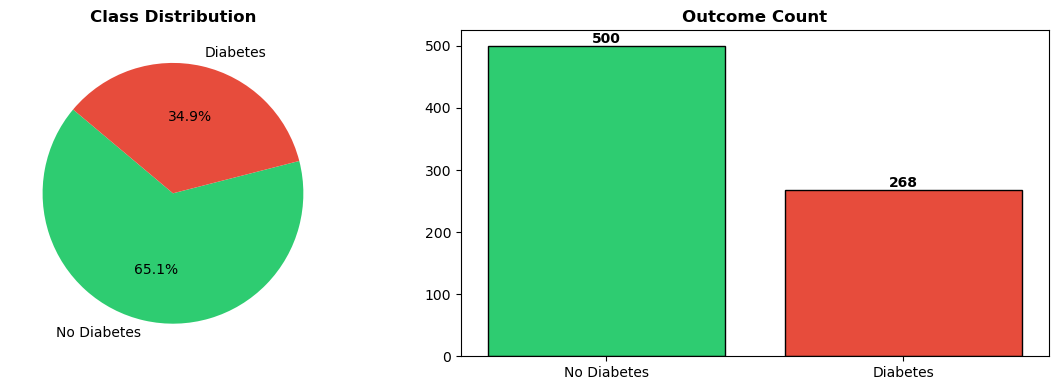

No Diabetes: 500  |  Diabetes: 268


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['Outcome'].value_counts()
labels = ['No Diabetes', 'Diabetes']
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Class Distribution', fontweight='bold')

axes[1].bar(labels, counts, color=colors, edgecolor='black')
axes[1].set_title('Outcome Count', fontweight='bold')
for i, v in enumerate(counts):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'No Diabetes: {counts[0]}  |  Diabetes: {counts[1]}')

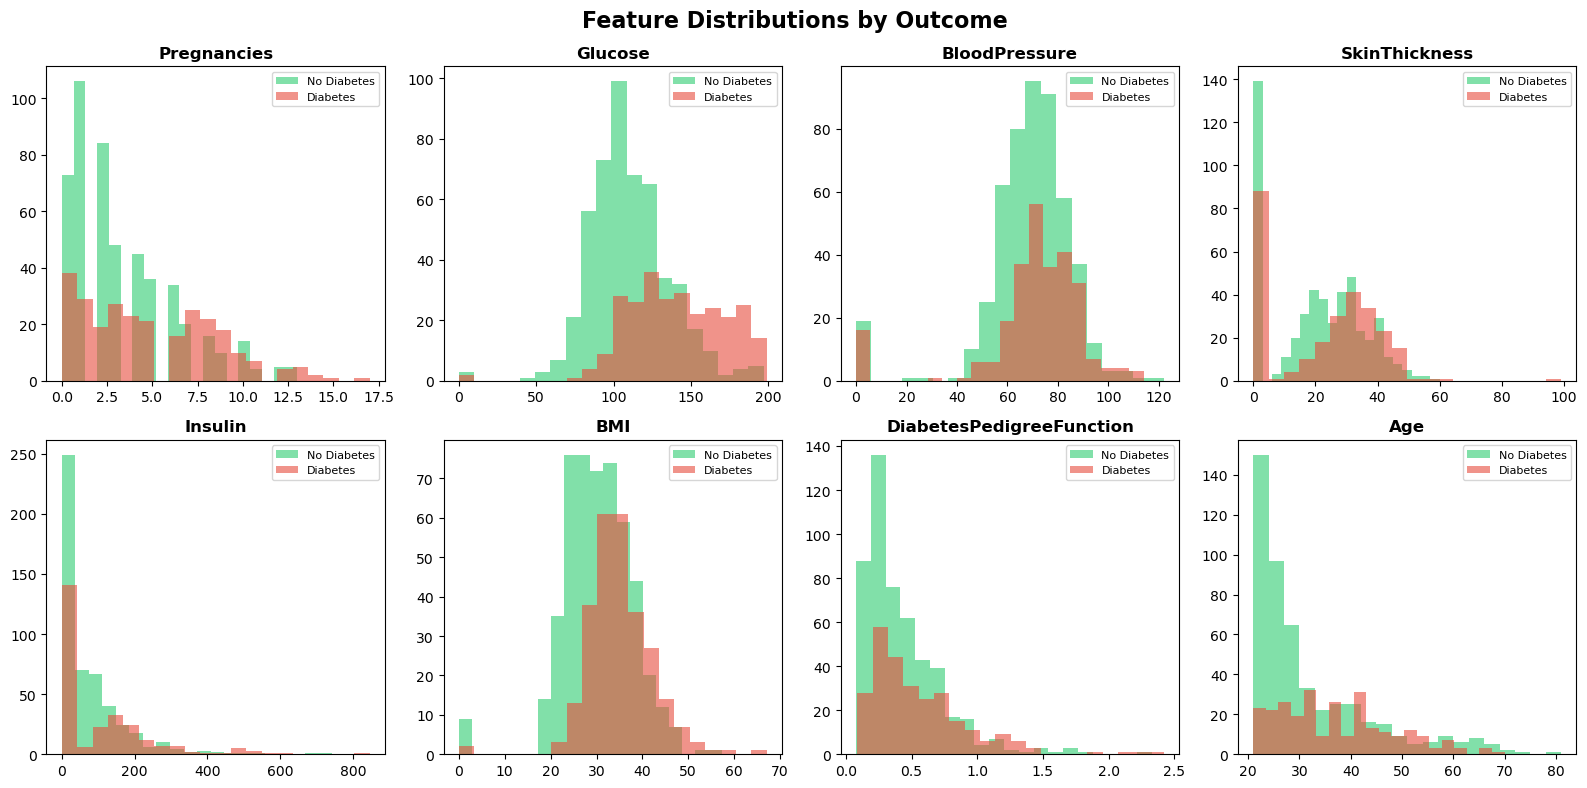

In [10]:
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][col], bins=20, alpha=0.6, color='#2ecc71', label='No Diabetes')
    axes[i].hist(df[df['Outcome']==1][col], bins=20, alpha=0.6, color='#e74c3c', label='Diabetes')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Outcome', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

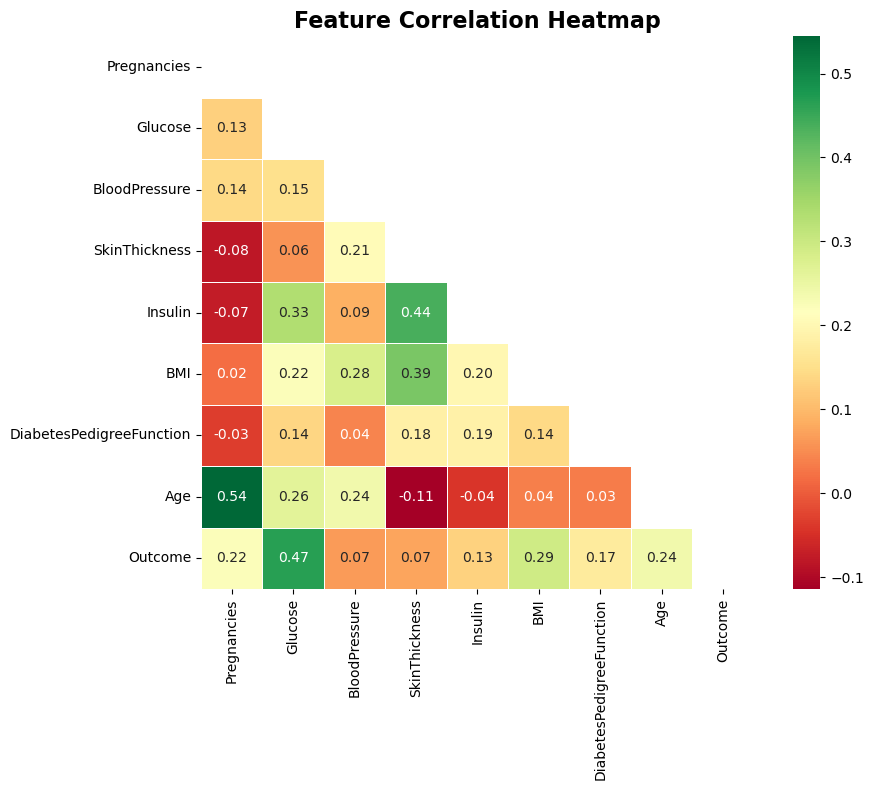

In [11]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Data Cleaning

In [12]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero values (biologically impossible):')
for col in zero_cols:
    n = (df[col] == 0).sum()
    print(f'  {col:30s}: {n} zeros ({n/len(df)*100:.1f}%)')

Zero values (biologically impossible):
  Glucose                       : 5 zeros (0.7%)
  BloodPressure                 : 35 zeros (4.6%)
  SkinThickness                 : 227 zeros (29.6%)
  Insulin                       : 374 zeros (48.7%)
  BMI                           : 11 zeros (1.4%)


In [13]:
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

# Fill NaN with median grouped by Outcome
for col in zero_cols:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

print('Missing values after cleaning:')
print(df_clean.isnull().sum())
print('\nCleaned statistics:')
display(df_clean.describe().round(2))

Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Cleaned statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.68,72.39,29.09,141.75,32.43,0.47,33.24,0.35
std,3.37,30.46,12.11,8.89,89.10,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,102.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,28.00,102.50,32.05,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,169.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [14]:
# Cap outliers via IQR for skewed columns
for col in ['Insulin', 'SkinThickness']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    upper = Q3 + 3 * (Q3 - Q1)
    df_clean[col] = np.where(df_clean[col] > upper, upper, df_clean[col])
    print(f'{col}: capped at {upper:.1f}')
print('Outlier capping complete.')

Insulin: capped at 370.5
SkinThickness: capped at 53.0
Outlier capping complete.


## Step 5: Feature Engineering & Preprocessing

In [15]:
df_clean['Glucose_BMI']          = df_clean['Glucose'] * df_clean['BMI']
df_clean['Age_Pregnancies']      = df_clean['Age'] * df_clean['Pregnancies']
df_clean['Insulin_Glucose_ratio']= df_clean['Insulin'] / (df_clean['Glucose'] + 1)

print('New features added: Glucose_BMI, Age_Pregnancies, Insulin_Glucose_ratio')
print(f'Final dataset shape: {df_clean.shape}')

New features added: Glucose_BMI, Age_Pregnancies, Insulin_Glucose_ratio
Final dataset shape: (768, 12)


In [16]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set : {X_train_sc.shape}')
print(f'Testing set  : {X_test_sc.shape}')

Training set : (614, 11)
Testing set  : (154, 11)


## Step 6: Train Multiple Models

In [17]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv  = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy').mean()
    results.append({'Model': name, 'Test Accuracy': round(acc,4),
                    'ROC-AUC': round(auc,4), 'CV Accuracy': round(cv,4)})
    print(f'{name:22s} | Acc: {acc:.4f} | AUC: {auc:.4f} | CV: {cv:.4f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(results_df)

Logistic Regression    | Acc: 0.7338 | AUC: 0.8306 | CV: 0.7981
Decision Tree          | Acc: 0.8571 | AUC: 0.8389 | CV: 0.8126
Random Forest          | Acc: 0.8766 | AUC: 0.9469 | CV: 0.8729
Gradient Boosting      | Acc: 0.8896 | AUC: 0.9576 | CV: 0.8762
SVM                    | Acc: 0.8442 | AUC: 0.9048 | CV: 0.8404
KNN                    | Acc: 0.8636 | AUC: 0.8824 | CV: 0.8290


,Model,Test Accuracy,ROC-AUC,CV Accuracy
0,Gradient Boosting,0.8896,0.9576,0.8762
1,Random Forest,0.8766,0.9469,0.8729
2,SVM,0.8442,0.9048,0.8404
3,KNN,0.8636,0.8824,0.8290
4,Decision Tree,0.8571,0.8389,0.8126
5,Logistic Regression,0.7338,0.8306,0.7981


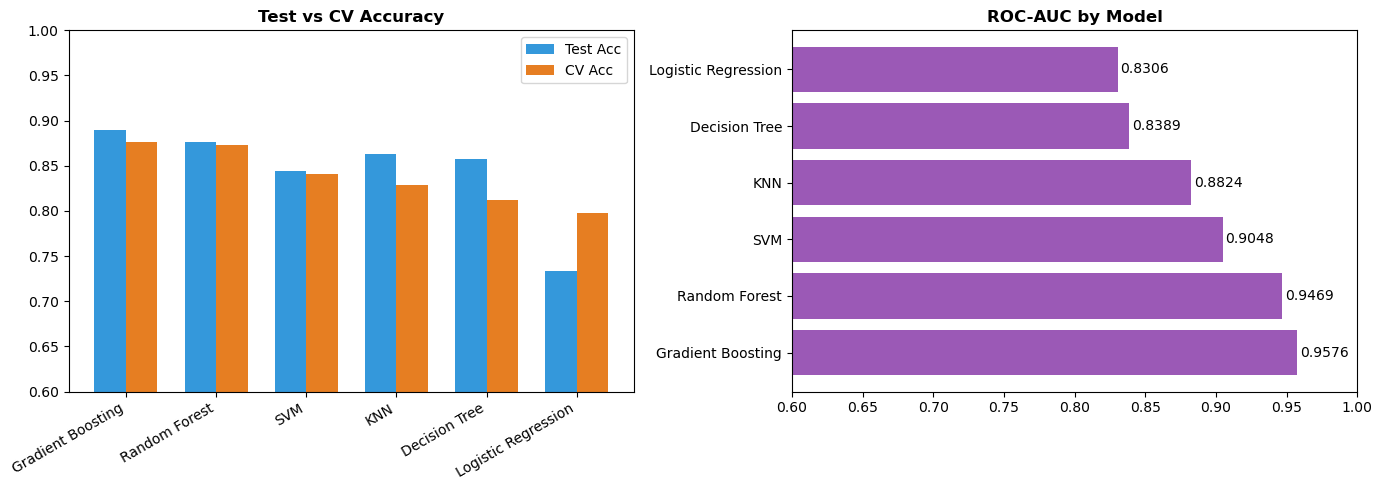

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(results_df))
w = 0.35
axes[0].bar(x - w/2, results_df['Test Accuracy'], w, label='Test Acc', color='#3498db')
axes[0].bar(x + w/2, results_df['CV Accuracy'],   w, label='CV Acc',   color='#e67e22')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=30, ha='right')
axes[0].set_ylim(0.6, 1.0)
axes[0].set_title('Test vs CV Accuracy', fontweight='bold')
axes[0].legend()

axes[1].barh(results_df['Model'], results_df['ROC-AUC'], color='#9b59b6')
axes[1].set_xlim(0.6, 1.0)
axes[1].set_title('ROC-AUC by Model', fontweight='bold')
for i, v in enumerate(results_df['ROC-AUC']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

## Step 7: Hyperparameter Tuning (Random Forest)

In [19]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}
rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train_sc, y_train)

print(f'Best Parameters : {grid.best_params_}')
print(f'Best CV ROC-AUC : {grid.best_score_:.4f}')
best_model = grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC : 0.9375


## Step 8: Evaluation – Confusion Matrix & ROC Curve

In [20]:
y_pred_best  = best_model.predict(X_test_sc)
y_proba_best = best_model.predict_proba(X_test_sc)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No Diabetes','Diabetes']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}')

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.90      0.91      0.91       100
    Diabetes       0.83      0.81      0.82        54

    accuracy                           0.88       154
   macro avg       0.87      0.86      0.86       154
weighted avg       0.88      0.88      0.88       154

ROC-AUC: 0.9500


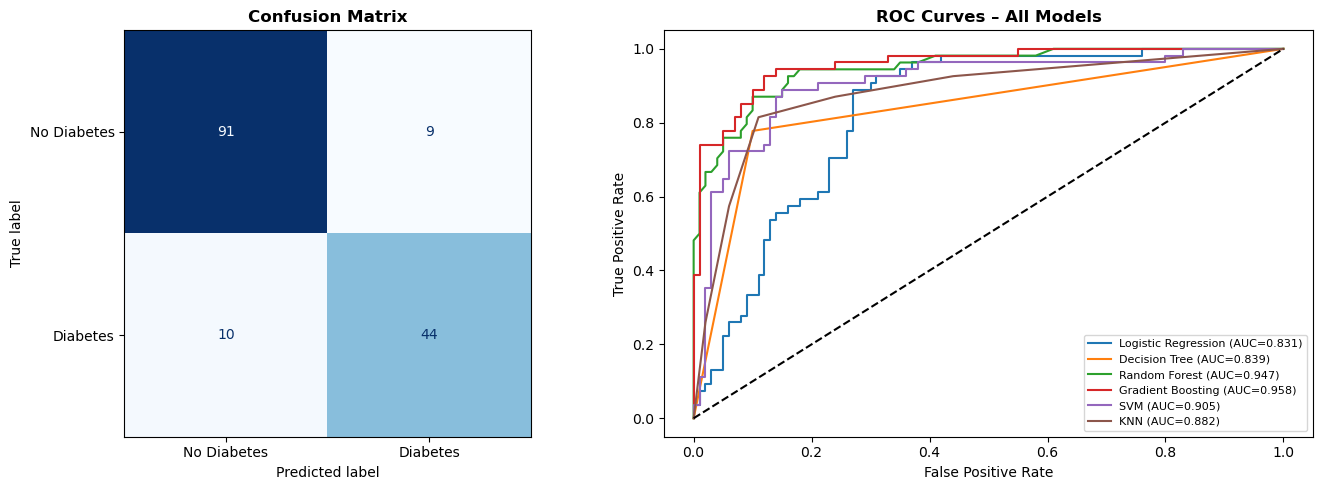

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes','Diabetes']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')

for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_sc)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves – All Models', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## Step 9: Feature Importance

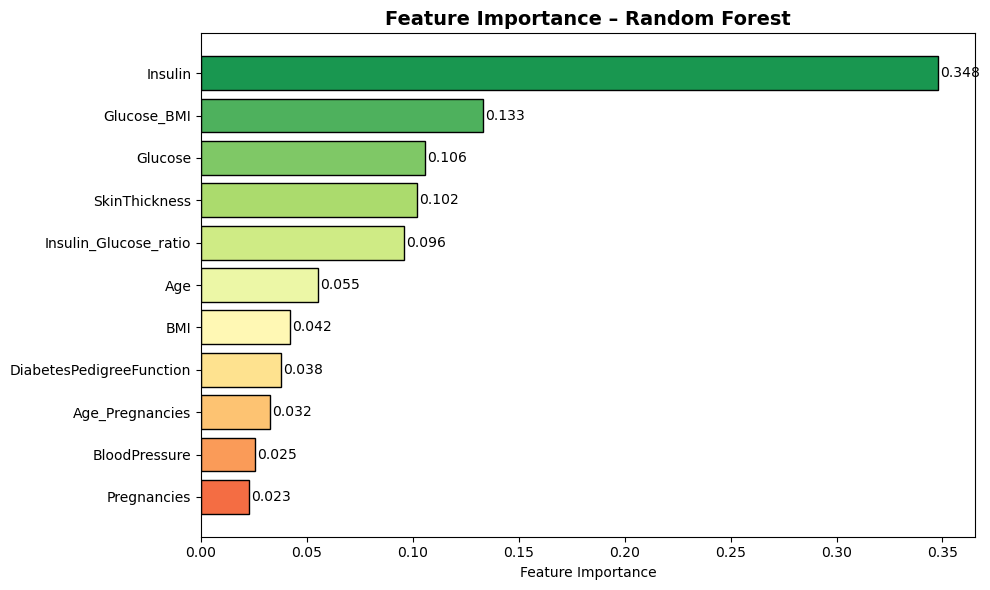

In [22]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
bars = plt.barh(importances.index, importances.values, color=colors, edgecolor='black')
plt.xlabel('Feature Importance')
plt.title('Feature Importance – Random Forest', fontweight='bold', fontsize=14)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

## Step 10: Predict New Patients

In [23]:
def predict_diabetes(patient_data):
    inp = pd.DataFrame([patient_data])
    inp['Glucose_BMI']           = inp['Glucose'] * inp['BMI']
    inp['Age_Pregnancies']       = inp['Age'] * inp['Pregnancies']
    inp['Insulin_Glucose_ratio'] = inp['Insulin'] / (inp['Glucose'] + 1)
    inp_sc    = scaler.transform(inp)
    pred      = best_model.predict(inp_sc)[0]
    prob      = best_model.predict_proba(inp_sc)[0]
    print('=' * 50)
    print('        DIABETES PREDICTION RESULT')
    print('=' * 50)
    for k, v in patient_data.items():
        print(f'  {k:30s}: {v}')
    print('-' * 50)
    print(f'  Probability No Diabetes : {prob[0]*100:.1f}%')
    print(f'  Probability Diabetes    : {prob[1]*100:.1f}%')
    print('-' * 50)
    if pred == 1:
        print('  RESULT: DIABETIC - Please consult a doctor.')
    else:
        print('  RESULT: NON-DIABETIC - Stay healthy!')
    print('=' * 50)

# High risk patient
patient1 = {
    'Pregnancies':6,'Glucose':148,'BloodPressure':72,
    'SkinThickness':35,'Insulin':0,'BMI':33.6,
    'DiabetesPedigreeFunction':0.627,'Age':50
}
# Low risk patient
patient2 = {
    'Pregnancies':1,'Glucose':85,'BloodPressure':66,
    'SkinThickness':29,'Insulin':0,'BMI':26.6,
    'DiabetesPedigreeFunction':0.351,'Age':31
}

print('--- Patient 1 (High Risk) ---')
predict_diabetes(patient1)
print()
print('--- Patient 2 (Low Risk) ---')
predict_diabetes(patient2)

--- Patient 1 (High Risk) ---
        DIABETES PREDICTION RESULT
  Pregnancies                   : 6
  Glucose                       : 148
  BloodPressure                 : 72
  SkinThickness                 : 35
  Insulin                       : 0
  BMI                           : 33.6
  DiabetesPedigreeFunction      : 0.627
  Age                           : 50
--------------------------------------------------
  Probability No Diabetes : 71.9%
  Probability Diabetes    : 28.1%
--------------------------------------------------
  RESULT: NON-DIABETIC - Stay healthy!

--- Patient 2 (Low Risk) ---
        DIABETES PREDICTION RESULT
  Pregnancies                   : 1
  Glucose                       : 85
  BloodPressure                 : 66
  SkinThickness                 : 29
  Insulin                       : 0
  BMI                           : 26.6
  DiabetesPedigreeFunction      : 0.351
  Age                           : 31
--------------------------------------------------
  Probabili

In [24]:
# Edit this cell to test your own patient
my_patient = {
    'Pregnancies'             : 2,
    'Glucose'                 : 120,
    'BloodPressure'           : 70,
    'SkinThickness'           : 20,
    'Insulin'                 : 85,
    'BMI'                     : 28.5,
    'DiabetesPedigreeFunction': 0.45,
    'Age'                     : 35
}

predict_diabetes(my_patient)

        DIABETES PREDICTION RESULT
  Pregnancies                   : 2
  Glucose                       : 120
  BloodPressure                 : 70
  SkinThickness                 : 20
  Insulin                       : 85
  BMI                           : 28.5
  DiabetesPedigreeFunction      : 0.45
  Age                           : 35
--------------------------------------------------
  Probability No Diabetes : 92.0%
  Probability Diabetes    : 8.0%
--------------------------------------------------
  RESULT: NON-DIABETIC - Stay healthy!
